In [1]:
import equinox as eqx
import jax.numpy as jnp
import pandas as pd
import warnings

from dmm.config_options import Conf
from dmm.initialisation import get_features_filepath, process_features_and_setup_models
from dmm.training_helper_funcs import create_pypesto_problem, rmse

from common import FEATURES_OUTFILE
from dataclasses import replace
from evaluation_utils import load_model
from util import load_petab_base_files
from training_configuration import SPLITS

warnings.filterwarnings("ignore")


/Users/fabring/dmm_env_310/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotat

In [2]:
def set_param_to_zero(
        model,
        param
):
    # Find parameter deviation index
    param_idx = model.parameter_deviation_names.index(param)
    # Extract binary mask and convert to JAX array
    new_output_sparsity_binary_mask = jnp.array(model.output_sparsity_binary_mask)
    # Set value to zero and convert back to tuple format
    new_output_sparsity_binary_mask = new_output_sparsity_binary_mask.at[param_idx].set(0)
    new_output_sparsity_binary_mask = tuple(new_output_sparsity_binary_mask.tolist())
    # Replace inside model and return new model instance
    return eqx.tree_at(
        lambda model: model.output_sparsity_binary_mask,
        model,
        new_output_sparsity_binary_mask,
    )

In [ ]:
from tqdm import tqdm

conf = Conf(
    model = "EGFR_MAPK__logobs",  # base model
    data = "dream_cytof",
    n_hidden = 6,
    depth = 0,
    dropout_rate=0.1,
    l1reg_inflater_output = 1e-2,
    inflater_output_reg_epoch=200,
    inflater_bound=3,
    l2reg_inflater_output = 0,
    recon_loss=1e-4,
    n_epoch=500,
    multiheaded=False,
)

# parameters_interest = [
#     "EGFR_p_Y1173_EGF_0_kw",
#     "ERBB2_p_Y1248_EGFR__Y1173_p_kw",
#     "ERBB2_p_Y1248_ERBB2_kw"
# ]
parameters_interest = None


# Load petab_base_files (once only)
petab_base_files = load_petab_base_files(conf)


res = []
for context, feature_sel in zip(
        [
            # "cytof_init",
            "multimodal"
        ],
        [
            # "RFE_15_permute",
            "RFE_10_permute"
        ]
):
    subconf = replace(conf, context=context, features=feature_sel)
    if context == "multimodal":
        subconf = replace(subconf, multiheaded=True)
    for samples in sorted(SPLITS):
        print(f"Now analysing {context}, {samples}...")
        subconf = replace(subconf, samples=samples)
        # Get filepaths for features and feature transformation pipeline
        features_filepath = get_features_filepath(subconf, FEATURES_OUTFILE)

        for job in range(10):
            subconf = replace(subconf, job=job)
            (
                _,
                problem,
                pypesto_subproblems,
                features,
            ) = process_features_and_setup_models(
                conf=subconf,
                features_filepath=features_filepath,
                petab_base_files=petab_base_files,
                dataset="train+val",
            )

            model = load_model(subconf, pypesto_subproblems["train"])
            print(f"Model loaded successfully for job {job}.")

            # Get list of parameter deviation names to perturb
            if parameters_interest is None:
                parameters_interest = model.parameter_deviation_names

            pypesto_problems = {
                dataset: create_pypesto_problem(pypesto_subproblems[dataset])
                for dataset in ["train", "val"]
            }

            # Precompute pristine RMSEs once per dataset
            rmse_pristine = {}
            for dataset in ["train", "val"]:
                rmse_pristine[dataset] = float(rmse(pypesto_problems[dataset], model, features[dataset].values))

            for param in tqdm(parameters_interest):
                new_model = set_param_to_zero(
                    model, param
                )
                for dataset in ["train", "val"]:
                    rmse_zeroed = rmse(pypesto_problems[dataset], new_model, features[dataset].values)
                    res.append(
                        {
                            "context": context,
                            "samples": samples,
                            "job": job,
                            "param": param,
                            "dataset": dataset,
                            "rmse_pristine": rmse_pristine[dataset],
                            "rmse_zeroed": rmse_zeroed,
                            "rmse_diff": rmse_zeroed - rmse_pristine[dataset],
                        }
                    )

results = pd.DataFrame(res)

Now analysing multimodal, BT20...
Model loaded successfully for job 0.


 34%|███▍      | 15/44 [00:12<00:20,  1.39it/s]

In [5]:
results = pd.read_csv("sensitivity_analysis_cytof_init_base_p38_nhidden6.csv")

In [11]:
import pandas as pd
results_df = pd.read_csv("sensitivity_analysis_cytof_init_base_p38_nhidden6.csv")
# Look at multimodal, validation
val_results = results_df[
    (results_df.dataset == "val")
]

val_results = pd.pivot_table(
    val_results,
    values="rmse_diff",
    columns="param",
    index="samples",
    aggfunc="mean"
)

In [12]:
val_results

param,EGFR_deg_EGF_0_kw,EGFR_deg_bact,EGFR_deg_kdeg,EGFR_dp_Y1173_kcat,EGFR_endo_EGFR_kw,EGFR_endo_ERBB2_kw,EGFR_endo_ERK__Y204_p_kw,EGFR_endo_bact,EGFR_p_Y1173_EGF_0_kw,EGFR_p_Y1173_bact,...,MEK_p_S222_bact,MEK_p_S222_iMEK_0_kw,RPS6KA1_dp_S380_kcat,RPS6KA1_p_S380_ERK__Y204_p_kw,RPS6KA1_p_S380_bact,TOPK_dp_Y74_kcat,TOPK_p_Y74_EGFR__Y1173_p_kw,TOPK_p_Y74_ERBB2__Y1248_p_kw,TOPK_p_Y74_ERBB3__Y1289_p_kw,TOPK_p_Y74_bact
samples,,,,,,,,,,,,,,,,,,,,,
BT20,3.249197e-02,0.000000,-0.022952,0.006165,-0.007119,0.000000,-0.001018,-0.000225,0.000000,0.000000,...,0.000000,0.000000,-0.002391,0.026986,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
EVSAT,0.000000e+00,0.000000,0.001290,0.000928,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000435,0.000000,-0.002984,0.096628,-0.004395,-0.000005,0.000231,0.000000,0.0,0.000000
HCC1500,3.327772e-02,0.000000,-0.085783,0.000000,0.000000,-0.049730,-0.000066,-0.042169,0.026991,0.000000,...,0.000000,0.000000,0.012880,0.173705,0.000000,0.000000,0.171399,-0.026318,0.0,0.000000
HCC2185,0.000000e+00,0.000000,-0.003865,0.004093,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.000820,0.000000,-0.004555,0.103107,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
MCF7,0.000000e+00,0.003185,0.004633,0.006118,0.000000,0.000000,0.000000,0.000000,0.004832,0.000000,...,0.000102,-0.000838,0.000000,0.004201,-0.003812,0.000000,0.025462,-0.000043,0.0,-0.007959
UACC3199,7.759626e-07,0.000000,-0.000016,0.000000,0.000000,0.000079,0.000000,0.000058,-0.010576,0.000434,...,0.000006,0.000000,0.000000,0.062852,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
UACC893,0.000000e+00,-0.000136,0.000000,0.000000,0.000000,0.000000,-0.000340,0.000000,0.000000,0.000000,...,0.000000,0.005393,-0.005377,0.332166,-0.100058,0.000000,0.000000,0.000000,0.0,0.000000


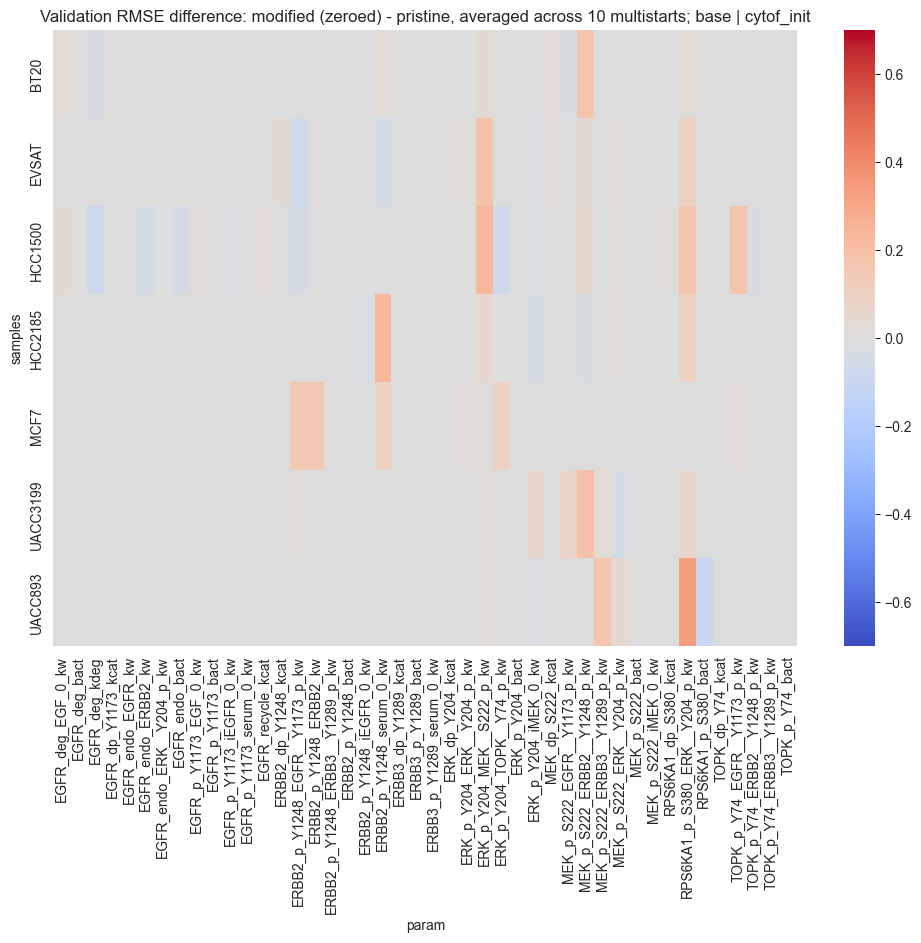

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(val_results, cmap="coolwarm", vmin=-0.7, vmax=0.7, xticklabels=val_results.columns)
plt.title("Validation RMSE difference: modified (zeroed) - pristine, averaged across 10 multistarts; base | cytof_init");
# plt.savefig("sensitivity_analysis_multimodal_base.png")

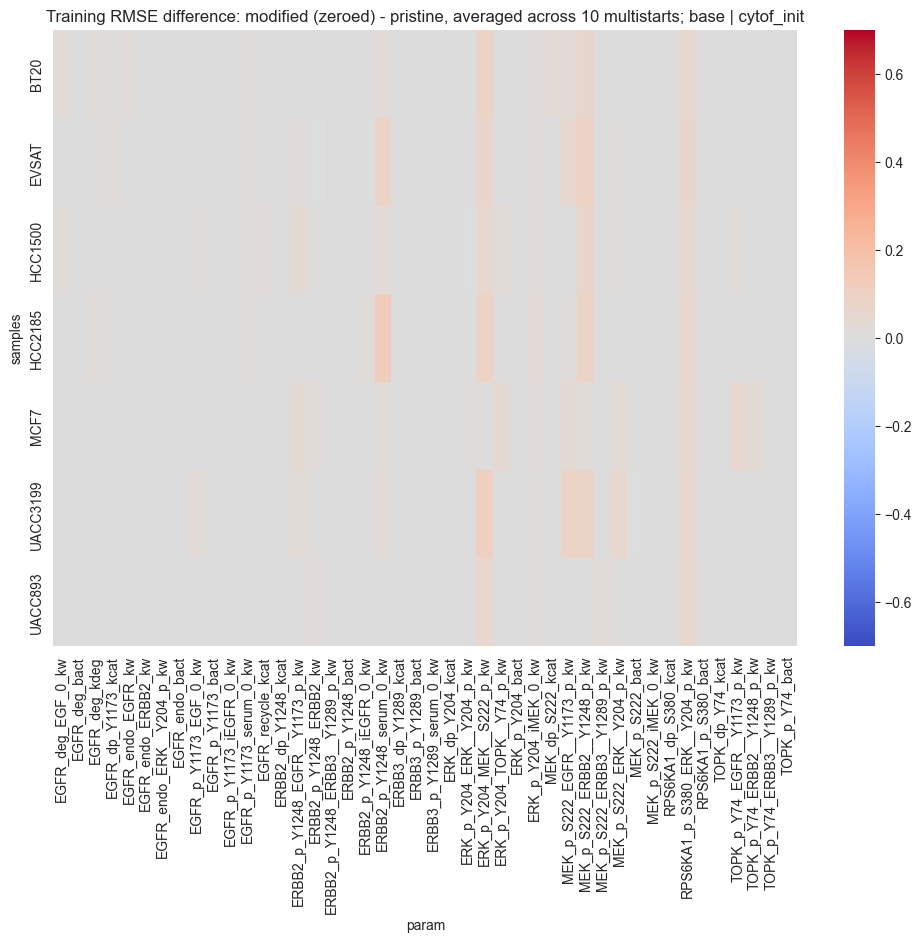

In [15]:
# Look at multimodal, validation
train_results = results_df[
    (results_df.dataset == "train") & (results_df.context == "cytof_init")
]

train_results = pd.pivot_table(
    train_results,
    values="rmse_diff",
    columns="param",
    index="samples",
    aggfunc="mean"
)

plt.figure(figsize=(12, 8))
sns.heatmap(train_results, cmap="coolwarm", vmin=-0.7, vmax=0.7, xticklabels=train_results.columns)
plt.title("Training RMSE difference: modified (zeroed) - pristine, averaged across 10 multistarts; base | cytof_init");
# plt.savefig("sensitivity_analysis_multimodal_base_train.png")

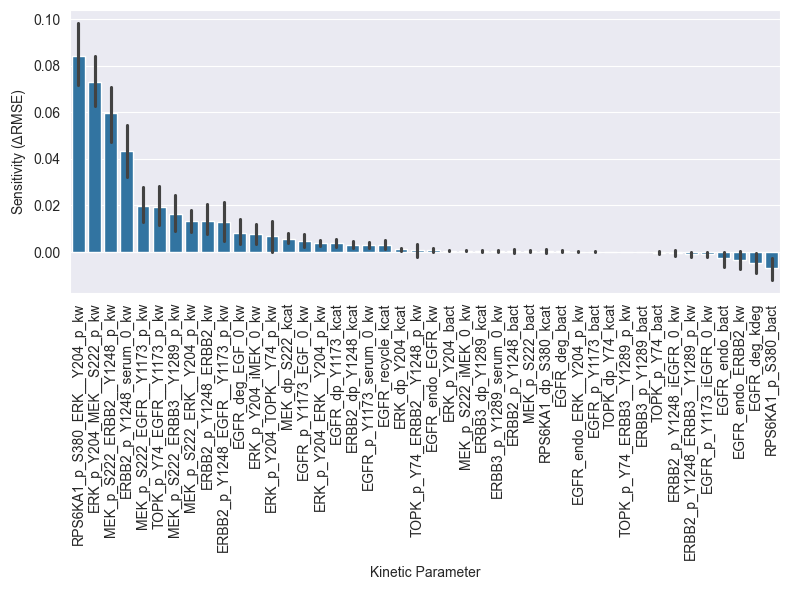

In [22]:
# filter to multimodal context
df = results_df[(results_df.context == "cytof_init")]

# compute mean rmse_diff per param
order = (
    df.groupby("param")["rmse_diff"]
      .mean()
      .sort_values(ascending=False)
      .index
)

plt.figure(figsize=(8, 6))
# plot with that order
sns.barplot(
    data=df,
    x="param",
    y="rmse_diff",
    order=order,
)

plt.ylabel(r"Sensitivity ($\Delta$RMSE)")
plt.xlabel("Kinetic Parameter")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("mean_samples_sensitivity_cytof_init_base_p38_nhidden6.pdf")

plt.show()

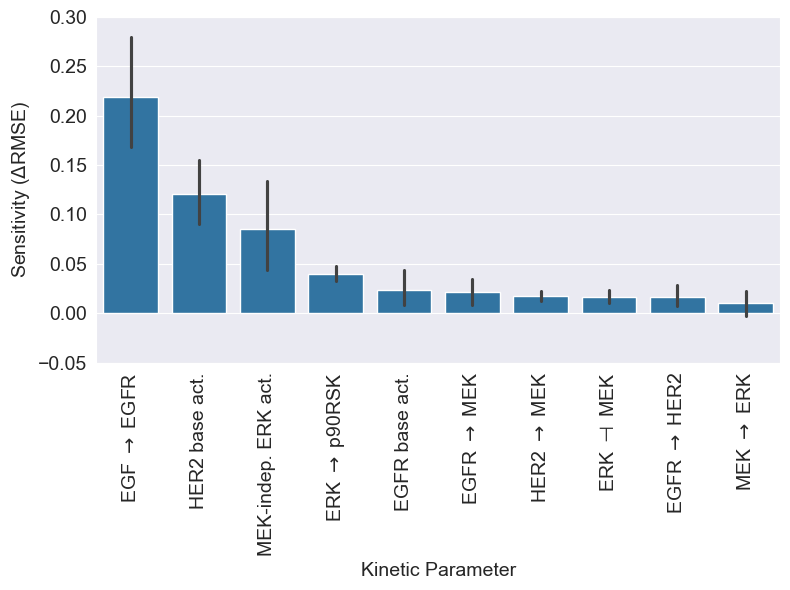

In [41]:
# filter to multimodal context
df = results_df[results_df.context == "multimodal"]

# compute mean rmse_diff per param
order = (
    df.groupby("param")["rmse_diff"]
      .mean()
      .sort_values(ascending=False)
      .index
)

# keep only the top 10
top10 = order[:10]

plt.figure(figsize=(8, 6))
sns.barplot(
    data=df[df["param"].isin(top10)],  # subset data
    x="param",
    y="rmse_diff",
    order=top10,                       # control order
)

plt.ylabel(r"Sensitivity ($\Delta$RMSE)", fontsize=14)
plt.xlabel("Kinetic Parameter", fontsize=14)
plt.xticks(
    plt.gca().get_xticks(),
    labels=[
        r"EGF $\rightarrow$ EGFR",
        "HER2 base act.",
        "MEK-indep. ERK act.",
        r"ERK $\rightarrow$ p90RSK",
        "EGFR base act.",
        r"EGFR $\rightarrow$ MEK",
        r"HER2 $\rightarrow$ MEK",
        r"ERK $\dashv$ MEK",
        r"EGFR $\rightarrow$ HER2",
        r"MEK $\rightarrow$ ERK"
    ],
    rotation=90,
    fontsize=14
)
plt.yticks(plt.gca().get_yticks(), fontsize=14)
plt.tight_layout()
plt.savefig("mean_samples_sensitivity_multimodal_top10.pdf")
plt.show()

In [91]:
# Look at multimodal, validation
val_results = results_df[
    (results_df.dataset == "val") & (results_df.context == "cytof_init")
]

val_results = pd.pivot_table(
    val_results,
    values="rmse_diff",
    columns="param",
    index="samples",
    aggfunc="mean"
)

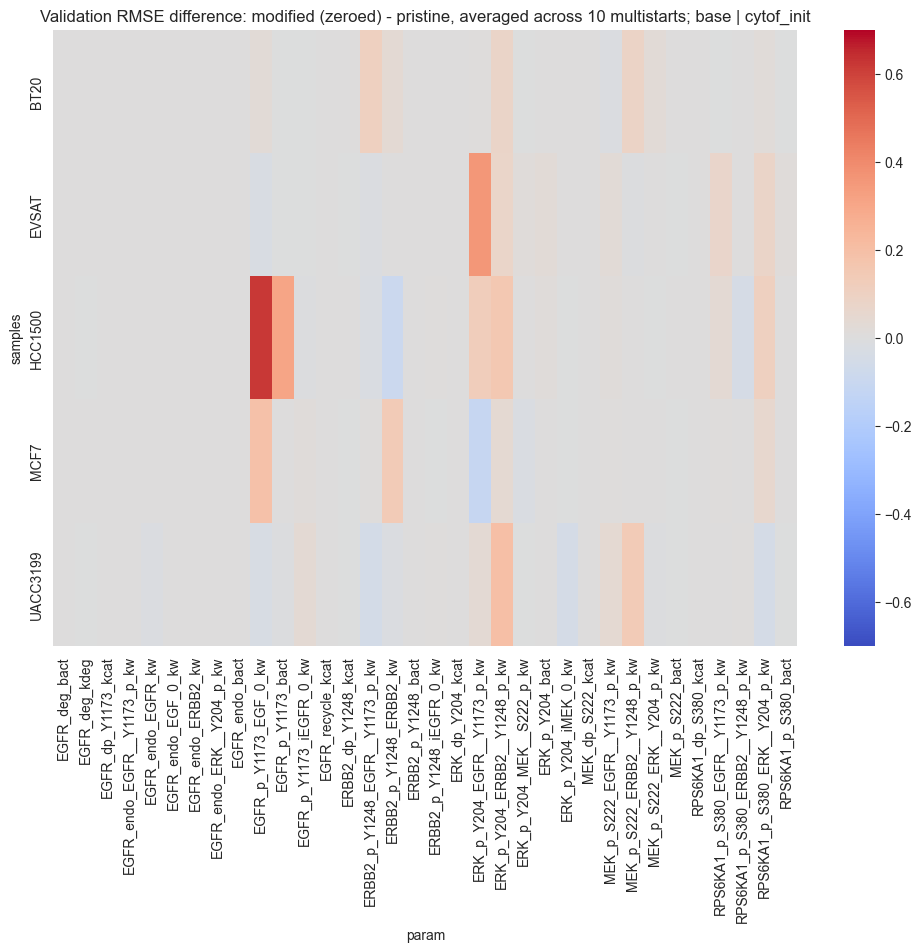

In [95]:
plt.figure(figsize=(12, 8))
sns.heatmap(val_results, cmap="coolwarm", vmin=-0.7, vmax=0.7, xticklabels=val_results.columns)
plt.title("Validation RMSE difference: modified (zeroed) - pristine, averaged across 10 multistarts; base | cytof_init");

# Zeroing latent embeddings

In [56]:
def zero_latent_direction(model, zero_idx: int, latent_dim: int = 2):
    """Return a copy of `model` whose deep_encoder output has dim `zero_idx` forced to 0."""
    assert 0 <= zero_idx < latent_dim, f"zero_idx must be in [0, {latent_dim-1}]"
    encoder_weights = model.deep_encoder.layers[0].weight
    masked_weights = encoder_weights.at[zero_idx].set(0)
    return eqx.tree_at(
        lambda m: m.deep_encoder.layers[0].weight,
        model,
        masked_weights
    )

In [81]:
from tqdm import tqdm

conf = Conf(
    model = "EGFR_MAPK__logobs",  # base model
    data = "dream_cytof",
    n_hidden = 2,
    depth = 0,
    l1reg_inflater_output = 1e-2,
    inflater_output_reg_epoch=200,
    inflater_bound=3,
    l2reg_inflater_output = 0,
    n_epoch=500,
)


# Load petab_base_files (once only)
petab_base_files = load_petab_base_files(conf)


res = []
for context, feature_sel in zip(
        [
            "cytof_init",
            "multimodal"
        ],
        [
            "RFE_10_permute",
            "best_RFE_10_permute"
        ]
):
    subconf = replace(conf, context=context, features=feature_sel)
    for samples in sorted(SPLITS):
        print(f"Now analysing {context}, {samples}...")
        subconf = replace(subconf, samples=samples)
        # Get filepaths for features and feature transformation pipeline
        features_filepath = get_features_filepath(subconf, FEATURES_OUTFILE)

        for job in range(10):
            subconf = replace(subconf, job=job)
            (
                _,
                problem,
                pypesto_subproblems,
                features,
            ) = process_features_and_setup_models(
                conf=subconf,
                features_filepath=features_filepath,
                petab_base_files=petab_base_files,
                dataset="train+val",
            )

            model = load_model(subconf, pypesto_subproblems["train"])
            print(f"Model loaded successfully for job {job}.")

            pypesto_problems = {
                dataset: create_pypesto_problem(pypesto_subproblems[dataset])
                for dataset in ["train", "val"]
            }

            # Precompute pristine RMSEs once per dataset
            rmse_pristine = {}
            for dataset in ["train", "val"]:
                rmse_pristine[dataset] = float(rmse(pypesto_problems[dataset], model, features[dataset].values))

            for latent_dimension in tqdm(range(2)):
                new_model = zero_latent_direction(model, latent_dimension)
                for dataset in ["train", "val"]:
                    rmse_zeroed = rmse(pypesto_problems[dataset], new_model, features[dataset].values)
                    res.append(
                        {
                            "context": context,
                            "samples": samples,
                            "job": job,
                            "latent_dimension": latent_dimension,
                            "dataset": dataset,
                            "rmse_pristine": rmse_pristine[dataset],
                            "rmse_zeroed": rmse_zeroed,
                            "rmse_diff": rmse_zeroed - rmse_pristine[dataset],
                        }
                    )

latent_results = pd.DataFrame(res)

Now analysing cytof_init, BT20...
Model loaded successfully for job 0.


100%|██████████| 2/2 [00:02<00:00,  1.30s/it]


Model loaded successfully for job 1.


100%|██████████| 2/2 [00:01<00:00,  1.74it/s]


Model loaded successfully for job 2.


...

100%|██████████| 2/2 [00:01<00:00,  1.11it/s]


Model loaded successfully for job 8.


100%|██████████| 2/2 [00:01<00:00,  1.81it/s]


Model loaded successfully for job 9.


100%|██████████| 2/2 [00:01<00:00,  1.73it/s]


In [84]:
latent_results.to_csv("latent_analysis_cytof_init_and_multimodal_base.csv", index=False)

## multimodal

In [103]:
latent_results_df = pd.read_csv("latent_analysis_cytof_init_and_multimodal_base.csv")
# Look at multimodal, validation
val_results = latent_results_df[
    (latent_results_df.dataset == "val") & (latent_results_df.context == "multimodal")
]

val_results = pd.pivot_table(
    val_results,
    values="rmse_diff",
    columns="latent_dimension",
    index="samples",
    aggfunc="mean"
)

In [104]:
val_results

latent_dimension,0,1
samples,,
BT20,0.129149,0.148478
EVSAT,0.362161,0.289748
HCC1500,0.413232,0.190287
MCF7,0.273892,0.248313
UACC3199,0.172694,0.152231


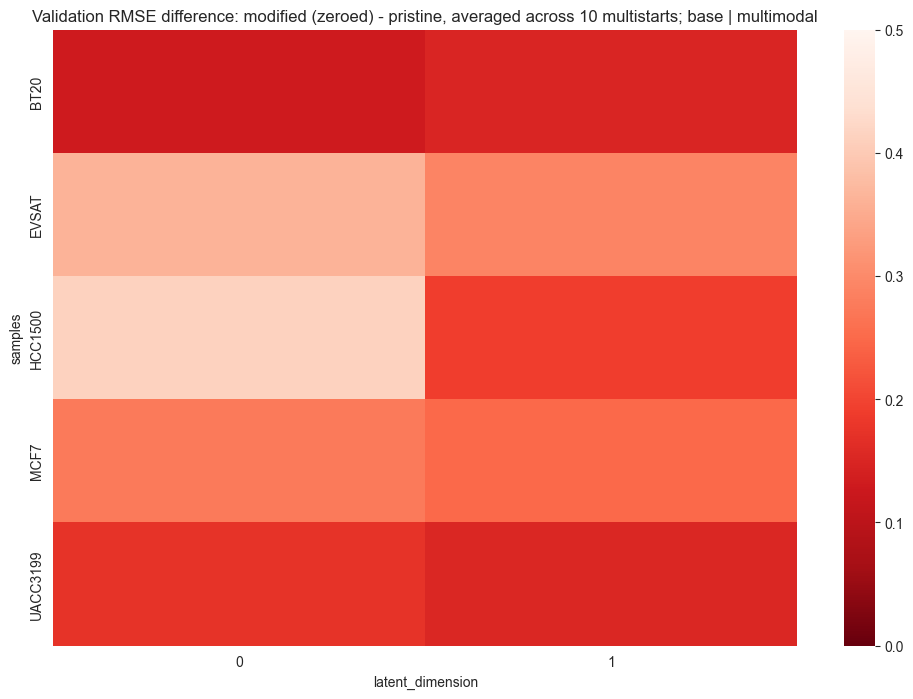

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(val_results, cmap="Reds_r", vmin=0, vmax=0.5, xticklabels=val_results.columns)
plt.title("Validation RMSE difference: modified (zeroed) - pristine, averaged across 10 multistarts; base | multimodal");
plt.savefig("latent_analysis_multimodal_base.png")

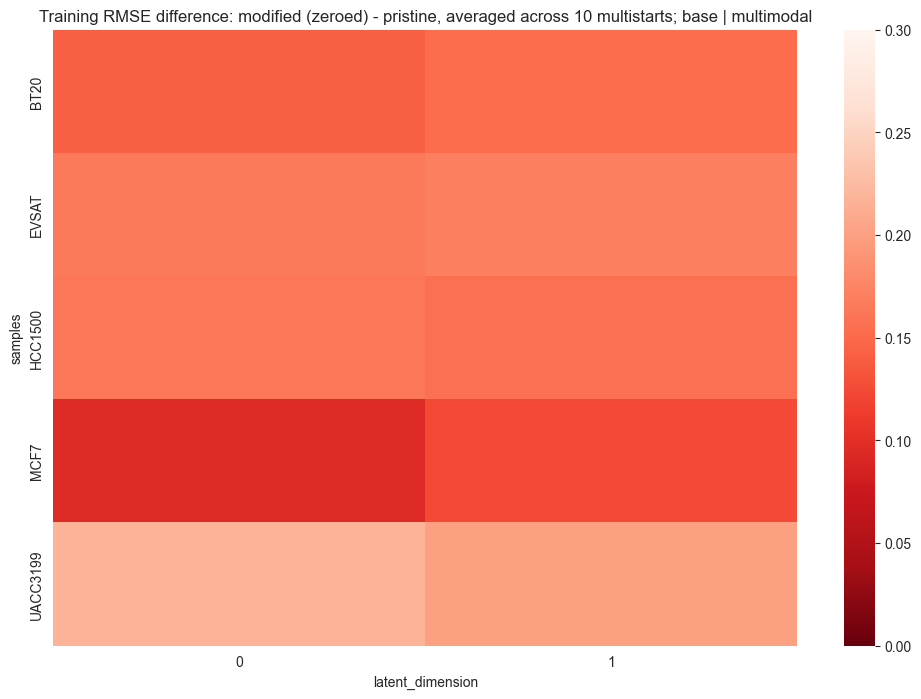

In [102]:
train_results = latent_results_df[
    (latent_results_df.dataset == "train") & (latent_results_df.context == "multimodal")
]

train_results = pd.pivot_table(
    train_results,
    values="rmse_diff",
    columns="latent_dimension",
    index="samples",
    aggfunc="mean"
)

plt.figure(figsize=(12, 8))
sns.heatmap(train_results, cmap="Reds_r", vmin=0, vmax=0.3, xticklabels=train_results.columns)
plt.title("Training RMSE difference: modified (zeroed) - pristine, averaged across 10 multistarts; base | multimodal");
plt.savefig("latent_analysis_multimodal_base_train.png")

## cytof_init

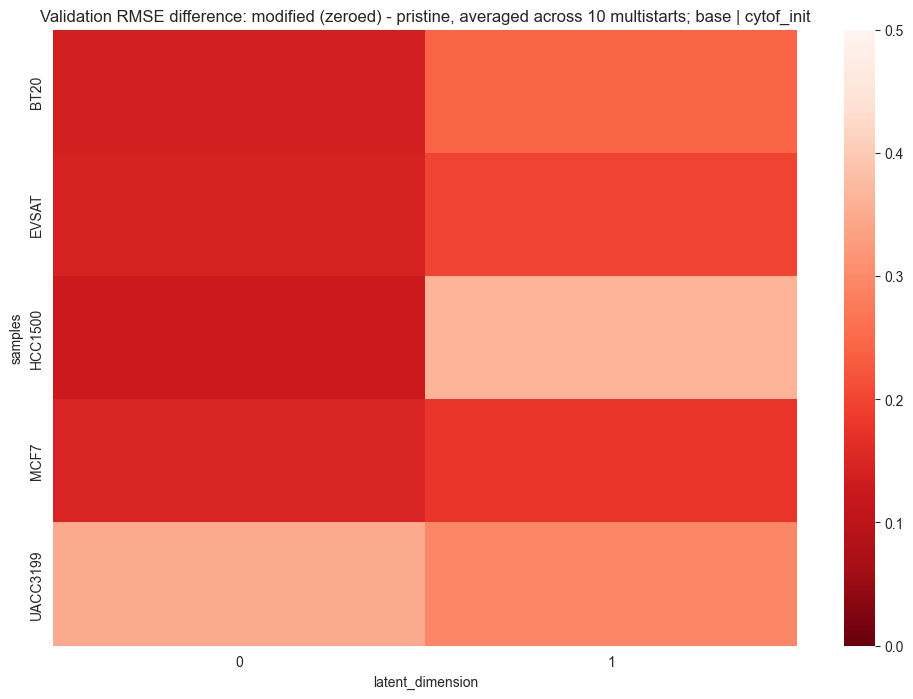

In [101]:
val_results = latent_results_df[
    (latent_results_df.dataset == "val") & (latent_results_df.context == "cytof_init")
]

val_results = pd.pivot_table(
    val_results,
    values="rmse_diff",
    columns="latent_dimension",
    index="samples",
    aggfunc="mean"
)

plt.figure(figsize=(12, 8))
sns.heatmap(val_results, cmap="Reds_r", vmin=0, vmax=0.5, xticklabels=val_results.columns)
plt.title("Validation RMSE difference: modified (zeroed) - pristine, averaged across 10 multistarts; base | cytof_init");
